In [6]:
import torch
import basicsr
import cv2

print("PyTorch:", torch.__version__)
print("CUDA доступна:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("BasicSR импортирован успешно.")
print("OpenCV:", cv2.__version__)

PyTorch: 2.11.0+cu130
CUDA доступна: True
GPU: Tesla T4
BasicSR импортирован успешно.
OpenCV: 5.0.0


In [23]:
from google.colab import files
from pathlib import Path
from google.colab import files
from pathlib import Path
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import cv2

uploaded = files.upload()

if not uploaded:
    raise ValueError("Фотография не выбрана.")

input_dir = Path("/content/Real-ESRGAN/inputs")
input_dir.mkdir(parents=True, exist_ok=True)

original_name, original_data = next(iter(uploaded.items()))

hr_path = input_dir / "dog_hr.jpg"
hr_path.write_bytes(original_data)

print("Исходное фото сохранено:", hr_path)

Saving photo.JPEG to photo (4).JPEG
Исходное фото сохранено: /content/Real-ESRGAN/inputs/dog_hr.jpg


In [25]:
input_dir = Path("/content/Real-ESRGAN/inputs")

hr_path = input_dir / "dog_hr.jpg"
lr_path = input_dir / "dog_lr.jpg"

hr_image = cv2.imread(str(hr_path), cv2.IMREAD_COLOR)

if hr_image is None:
    raise ValueError(f"Не удалось открыть изображение: {hr_path}")

height, width = hr_image.shape[:2]

print(f"Исходный размер: {width} × {height}")

new_width = width - (width % 4)
new_height = height - (height % 4)
hr_image = hr_image[:new_height, :new_width]
cv2.imwrite(str(hr_path), hr_image)

lr_image = cv2.resize(
    hr_image,
    (new_width // 4, new_height // 4),
    interpolation=cv2.INTER_AREA
)

cv2.imwrite(str(lr_path), lr_image)

print(f"HR после приведения: {new_width} × {new_height}")
print(f"LR после обработки: {new_width // 4} × {new_height // 4}")
print("Созданы файлы:")
print("-", hr_path.name)
print("-", lr_path.name)

Исходный размер: 590 × 879
HR после приведения: 588 × 876
LR после cv2.resize: 147 × 219
Созданы файлы:
- dog_hr.jpg
- dog_lr.jpg


HR — исходное фото: (588, 876)
LR — вход модели: (147, 219)
SR — результат Real-ESRGAN ×4: (588, 876)
Файл результата: dog_lr_out.jpg


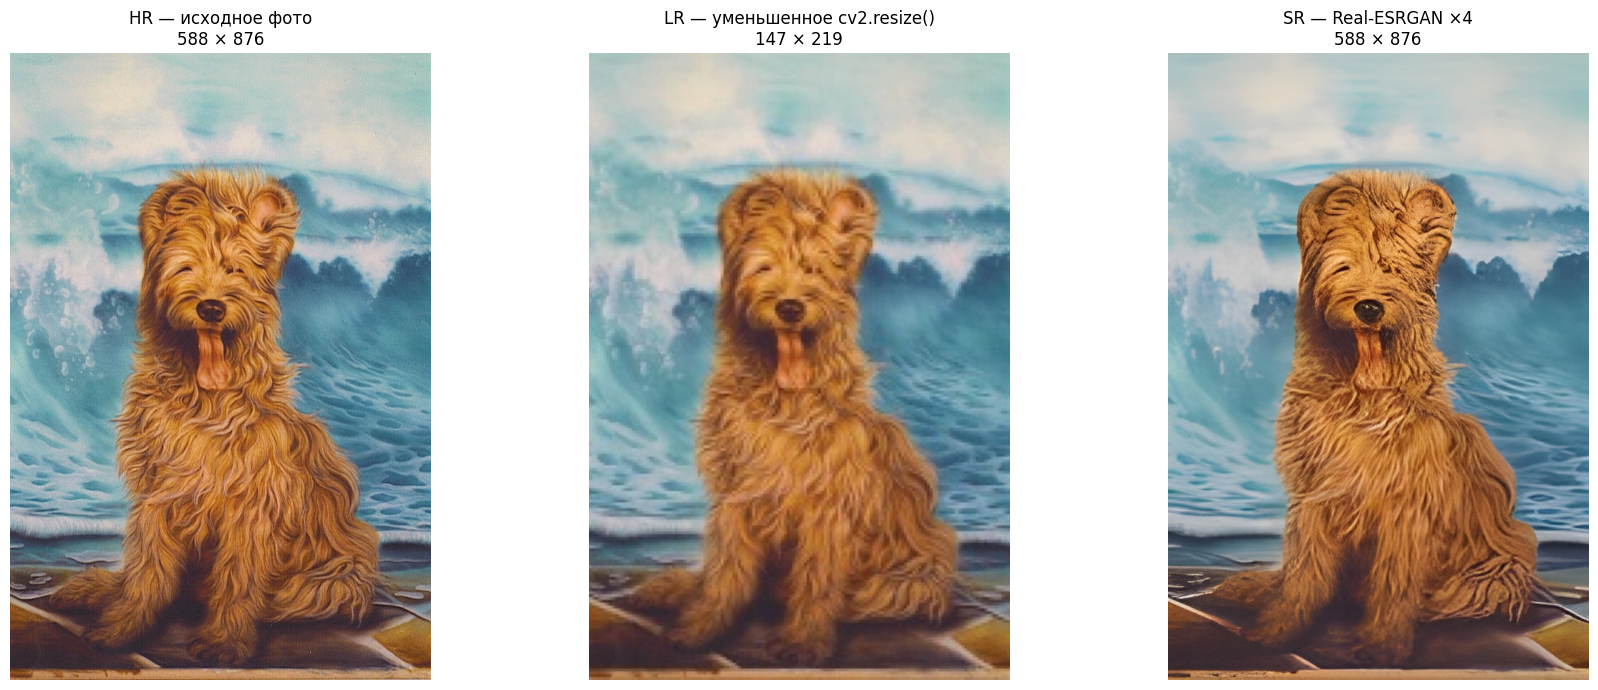

In [26]:
results_dir = Path("/content/Real-ESRGAN/results")


result_files = sorted(results_dir.glob("dog_lr_out.*"))

sr_path = result_files[0]

hr_image = Image.open(hr_path).convert("RGB")
lr_image = Image.open(lr_path).convert("RGB")
sr_image = Image.open(sr_path).convert("RGB")

print("HR — исходное фото:", hr_image.size)
print("LR — вход модели:", lr_image.size)
print("SR — результат Real-ESRGAN ×4:", sr_image.size)
print("Файл результата:", sr_path.name)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

images = [hr_image, lr_image, sr_image]
titles = [
    f"HR — исходное фото\n{hr_image.size[0]} × {hr_image.size[1]}",
    f"LR — уменьшенное изображение\n{lr_image.size[0]} × {lr_image.size[1]}",
    f"SR — Real-ESRGAN ×4\n{sr_image.size[0]} × {sr_image.size[1]}"
]

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
files.download(str(sr_path))